# Explainable AML modeling — simple MVP

This notebook compares **logistic regression, XGBoost, and Explainable Boosting Machine (EBM)** on IBM's synthetic HI-Small transaction data. It reads a reproducible 50% sample before September 11, builds a few transaction and past-activity features, makes a chronological train/validation/test split, and shows a result chart and explanation for each model. Run the cells from top to bottom.

This is a class demonstration on **sampled synthetic data**. A score ranks transactions for review; it is not a real laundering probability or an investigator conclusion. The [project guide](docs/PROJECT_GUIDE.md) explains the choices and limitations. The raw CSV stays local; tables and charts are saved in this notebook, not in a `results/` folder.

## 1. Imports and settings

Put `HI-Small_Trans.csv` at `data/raw/HI-Small_Trans.csv` as described in the [README](README.md). The seed selects the same 50% rows on repeated runs with the same CSV and row order.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score, confusion_matrix,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, DMatrix
from interpret.glassbox import ExplainableBoostingClassifier

DATA_PATH = Path("data/raw/HI-Small_Trans.csv")
SEED = 42
SAMPLE_FRACTION = 0.50
print("Dataset:", DATA_PATH)
print("Sample fraction:", SAMPLE_FRACTION)

Dataset: data/raw/HI-Small_Trans.csv
Sample fraction: 0.5


## 2. Load half the eligible transactions

The CSV has about five million rows. Reading it in chunks lets us keep 50% of transactions before September 11 without holding the entire file in pandas. The final days have an unusual volume and label rate, so this experiment leaves them out. Bank and account IDs are read as text to preserve leading zeros. The receiver account, received amount, and receiving currency are now included.

In [2]:
rng = np.random.default_rng(SEED)
parts = []
for chunk in pd.read_csv(
    DATA_PATH,
    chunksize=100_000,
    usecols=["Timestamp", "From Bank", "Account", "To Bank", "Account.1",
             "Amount Received", "Receiving Currency", "Amount Paid",
             "Payment Currency", "Payment Format", "Is Laundering"],
    dtype={"From Bank": str, "Account": str, "To Bank": str, "Account.1": str},
):
    timestamps = pd.to_datetime(chunk["Timestamp"])
    keep = (timestamps < "2022-09-11") & (rng.random(len(chunk)) < SAMPLE_FRACTION)
    parts.append(chunk.loc[keep])

transactions = pd.concat(parts, ignore_index=True).rename(columns={
    "Timestamp": "timestamp",
    "From Bank": "from_bank",
    "Account": "from_account",
    "To Bank": "to_bank",
    "Account.1": "to_account",
    "Amount Received": "amount_received",
    "Receiving Currency": "receiving_currency",
    "Amount Paid": "amount_paid",
    "Payment Currency": "payment_currency",
    "Payment Format": "payment_format",
    "Is Laundering": "label",
})
del parts, chunk
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])
transactions = transactions.sort_values("timestamp", kind="stable").reset_index(drop=True)
print(f"Sampled rows: {len(transactions):,}")
print(f"Positive labels: {transactions['label'].sum():,} ({transactions['label'].mean():.3%})")
display(transactions[["timestamp", "amount_paid", "payment_currency", "payment_format", "label"]].head())

Sampled rows: 2,539,464
Positive labels: 2,271 (0.089%)


,timestamp,amount_paid,payment_currency,payment_format,label
0,2022-09-01,897.37,US Dollar,Reinvestment,0
1,2022-09-01,10.30,US Dollar,Reinvestment,0
2,2022-09-01,18.51,US Dollar,Reinvestment,0
3,2022-09-01,400.56,US Dollar,Reinvestment,0
4,2022-09-01,12971.84,US Dollar,Reinvestment,0


## 3. Create transaction and past-activity features

The current transaction gives us paid and received amounts, hour, same-bank and same-account flags, format, and currencies. The three history counts measure earlier **sampled** transactions for the sender, receiver, and sender–receiver pair. We also compare the payment with that sender’s earlier average payment in the same currency. All four history features exclude transactions at the same timestamp, so a row never uses future or simultaneous activity. The average is log-transformed and is zero when no earlier same-currency payment exists.

We keep the original bank and account fields in `transactions` for inspection. The model uses them through the history and relationship features, rather than treating arbitrary account IDs as numeric or one-hot predictors. The [IBM benchmark](https://papers.nips.cc/paper/2023/file/5f38404edff6f3f642d6fa5892479c42-Paper-Datasets_and_Benchmarks.pdf) makes the same distinction to avoid memorizing IDs.

In [3]:
transactions["sender"] = transactions["from_bank"] + ":" + transactions["from_account"]
transactions["receiver"] = transactions["to_bank"] + ":" + transactions["to_account"]
for group_columns, feature_name in [
    (["sender"], "prior_sender_count"),
    (["receiver"], "prior_receiver_count"),
    (["sender", "receiver"], "prior_pair_count"),
]:
    transactions[feature_name] = (
        transactions.groupby(group_columns, sort=False).cumcount()
        - transactions.groupby(group_columns + ["timestamp"], sort=False).cumcount()
    )

# Typical earlier payment size for this sender and payment currency.
history_keys = ["sender", "payment_currency"]
earlier_amount = (
    transactions.groupby(history_keys, sort=False)["amount_paid"].cumsum()
    - transactions.groupby(history_keys + ["timestamp"], sort=False)["amount_paid"].cumsum()
)
earlier_count = (
    transactions.groupby(history_keys, sort=False).cumcount()
    - transactions.groupby(history_keys + ["timestamp"], sort=False).cumcount()
)
transactions["log_prior_sender_mean_amount"] = np.log1p(
    earlier_amount / earlier_count.replace(0, np.nan)
).fillna(0).astype(np.float32)
del earlier_amount, earlier_count

transactions["log_amount"] = np.log1p(transactions["amount_paid"])
transactions["log_amount_received"] = np.log1p(transactions["amount_received"])
transactions["hour"] = transactions["timestamp"].dt.hour
transactions["same_bank"] = (transactions["from_bank"] == transactions["to_bank"]).astype(int)
transactions["same_account"] = (transactions["sender"] == transactions["receiver"]).astype(int)
transactions = transactions.drop(columns=["sender", "receiver"])

print("Feature example:")
display(transactions[["log_amount", "log_amount_received", "prior_sender_count",
                      "prior_receiver_count", "prior_pair_count",
                      "log_prior_sender_mean_amount"]].head())

Feature example:


,log_amount,log_amount_received,prior_sender_count,prior_receiver_count,prior_pair_count,log_prior_sender_mean_amount
0,6.800582,6.800582,0,0,0,0.0
1,2.424803,2.424803,0,0,0,0.0
2,2.970927,2.970927,0,0,0,0.0
3,5.995357,5.995357,0,0,0,0.0
4,9.470613,9.470613,0,0,0,0.0


## 4. Split by time and encode categories

Training uses September 1–6 (**64.02%** of sampled rows), validation September 7–8 (**19.00%**), and September 9–10 is the later test/reporting period (**16.98%**). These percentages come from the fixed dates, not a forced 60/20/20 split. We choose a model and its decision threshold using validation data. Payment format and both currencies become numeric indicator columns using training categories only.

Why split by time? A monitoring model would score activity after training. A random split can put later behavior in training while testing on earlier, related transactions. History features use only earlier sampled rows, including earlier activity before each validation or test transaction.

In [4]:
feature_columns = ["log_amount", "log_amount_received", "hour", "same_bank",
                   "same_account", "prior_sender_count", "prior_receiver_count",
                   "prior_pair_count", "log_prior_sender_mean_amount",
                   "payment_format", "payment_currency",
                   "receiving_currency"]
categories = ["payment_format", "payment_currency", "receiving_currency"]
split_columns = ["timestamp", "label", "amount_paid", "amount_received"] + feature_columns
train = transactions.loc[transactions["timestamp"] < "2022-09-07", split_columns].copy()
validation = transactions.loc[
    (transactions["timestamp"] >= "2022-09-07") &
    (transactions["timestamp"] < "2022-09-09"), split_columns
].copy()
test = transactions.loc[transactions["timestamp"] >= "2022-09-09", split_columns].copy()

split_summary = pd.DataFrame({
    "period": ["train", "validation", "test"],
    "rows": [len(train), len(validation), len(test)],
    "positive_labels": [train["label"].sum(), validation["label"].sum(), test["label"].sum()],
})
split_summary["share_of_sample_pct"] = (100 * split_summary["rows"] / len(transactions)).round(2)
split_summary["positive_label_rate_pct"] = (100 * split_summary["positive_labels"] / split_summary["rows"]).round(4)
display(split_summary)

X_train = pd.get_dummies(train[feature_columns], columns=categories, dtype=np.float32)
X_validation = pd.get_dummies(validation[feature_columns], columns=categories, dtype=np.float32)
X_test = pd.get_dummies(test[feature_columns], columns=categories, dtype=np.float32)
X_train = X_train.astype(np.float32)
X_validation = X_validation.reindex(columns=X_train.columns, fill_value=0).astype(np.float32)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0).astype(np.float32)
y_train = train["label"]
y_validation = validation["label"]
y_test = test["label"]
print("Model features:", len(X_train.columns))
display(X_train.head())

,period,rows,positive_labels,share_of_sample_pct,positive_label_rate_pct
0,train,1625750,1260,64.02,0.0775
1,validation,482608,523,19.00,0.1084
2,test,431106,488,16.98,0.1132


Model features: 46


,log_amount,log_amount_received,hour,same_bank,same_account,prior_sender_count,prior_receiver_count,prior_pair_count,log_prior_sender_mean_amount,payment_format_ACH,...,receiving_currency_Mexican Peso,receiving_currency_Ruble,receiving_currency_Rupee,receiving_currency_Saudi Riyal,receiving_currency_Shekel,receiving_currency_Swiss Franc,receiving_currency_UK Pound,receiving_currency_US Dollar,receiving_currency_Yen,receiving_currency_Yuan
0,6.800582,6.800582,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2.424803,2.424803,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2.970927,2.970927,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,5.995357,5.995357,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,9.470613,9.470613,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 5. Fit the three models

Logistic regression is the linear baseline. XGBoost learns nonlinear tree patterns. EBM learns interpretable additive effects. All three fit only the training rows and use a moderate positive-class weight of 10. The earlier inverse-frequency weight was about 1,289 and gave worse validation rankings in our exploratory runs. These weights help the models learn from rare labels; the outputs are still not calibrated probabilities.

In [5]:
positive_weight = 10
weights = np.where(y_train == 1, positive_weight, 1.0)
models = {
    "Logistic regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=500)
    ),
    "XGBoost": XGBClassifier(
        n_estimators=120, max_depth=3, learning_rate=0.08,
        scale_pos_weight=positive_weight, tree_method="hist", n_jobs=4,
        eval_metric="logloss", random_state=SEED,
    ),
    "EBM": ExplainableBoostingClassifier(
        interactions=0, outer_bags=1, max_rounds=200, n_jobs=4, random_state=SEED
    ),
}
models["Logistic regression"].fit(
    X_train, y_train, logisticregression__sample_weight=weights
)
models["XGBoost"].fit(X_train, y_train)
models["EBM"].fit(X_train, y_train, sample_weight=weights)
print("Fitted:", ", ".join(models))

Fitted: Logistic regression, XGBoost, EBM


## 6. Evaluate with established classification metrics

**Average precision (AP, a summary of the precision–recall curve)** evaluates ranking across thresholds. For rare labels, the positive-label rate is its random-ranking baseline. **Precision, recall, and F1** evaluate binary alerts at a stated threshold. **False positive rate (FPR)** is false alerts divided by all normal transactions; the confusion matrix gives the counts. Each threshold is selected by the best F1 on validation data, then applied unchanged to the later reporting period.

The **illustrative class-project goal**, set before evaluating this revised feature on September 9–10, is at least **30% precision, 30% recall, 0.30 F1**, and **FPR below 0.1%**. These values are not regulatory or industry minimums. Precision and recall are explicitly discussed in industry AML guidance; F1, FPR, and AP are useful statistical measures for this labeled experiment. Actual risk coverage and SAR quality cannot be measured from this CSV. A bank would set outcomes against its own risk coverage, investigation capacity, and alert quality. The [Wolfsberg Group](https://wolfsberg-group.org/resources/195/202) recommends considering precision, recall, priority-risk coverage, and SAR quality; the [FFIEC manual](https://bsaaml.ffiec.gov/manual/AssessingComplianceWithBSARegulatoryRequirements/04) describes risk-based monitoring and review rather than numeric model cutoffs.

In [6]:
rows = []
scores = {}
thresholds = {}
for name, model in models.items():
    validation_score = model.predict_proba(X_validation)[:, 1]
    precision_curve, recall_curve, cutoff_values = precision_recall_curve(
        y_validation, validation_score
    )
    f1_curve = (
        2 * precision_curve[:-1] * recall_curve[:-1]
        / (precision_curve[:-1] + recall_curve[:-1] + 1e-12)
    )
    thresholds[name] = cutoff_values[np.argmax(f1_curve)]

    for period, X, y in [
        ("validation", X_validation, y_validation),
        ("test", X_test, y_test),
    ]:
        score = validation_score if period == "validation" else model.predict_proba(X)[:, 1]
        scores[(name, period)] = score
        alerts = score >= thresholds[name]
        tn, fp, fn, tp = confusion_matrix(y, alerts).ravel()
        rows.append({
            "model": name,
            "period": period,
            "average_precision": average_precision_score(y, score),
            "precision": precision_score(y, alerts, zero_division=0),
            "recall": recall_score(y, alerts),
            "f1": f1_score(y, alerts),
            "false_positive_rate": fp / (fp + tn),
            "true_positives": int(tp),
            "false_positives": int(fp),
            "alerts": int(alerts.sum()),
        })
results = pd.DataFrame(rows)
selected_model = (
    results[results["period"] == "validation"]
    .sort_values("average_precision", ascending=False)
    .iloc[0]["model"]
)
print("Selected using validation AP:", selected_model)
print("Positive-label rate: validation", round(y_validation.mean(), 4),
      "reporting period", round(y_test.mean(), 4))
display(results.round(4))
selected_alerts = scores[(selected_model, "test")] >= thresholds[selected_model]
print("Validation-selected threshold for", selected_model, ":", round(thresholds[selected_model], 4))
display(pd.DataFrame(
    confusion_matrix(y_test, selected_alerts),
    index=["actual normal", "actual laundering"],
    columns=["no alert", "alert"],
))

later = results[(results["model"] == selected_model) & (results["period"] == "test")].iloc[0]
print("Illustrative class-project goal on the later period:")
for metric, target in [("precision", 0.30), ("recall", 0.30), ("f1", 0.30)]:
    print(f"{metric}: {later[metric]:.2%} (goal at least {target:.0%}) —",
          "met" if later[metric] >= target else "not met")
print(f"false positive rate: {later['false_positive_rate']:.3%} (goal below 0.1%) —",
      "met" if later["false_positive_rate"] < 0.001 else "not met")

top = np.argsort(-scores[(selected_model, "test")])[:10]
top_transactions = test.iloc[top][[
    "timestamp", "amount_paid", "payment_currency", "amount_received",
    "receiving_currency", "payment_format", "label"
]].copy()
top_transactions["model_score"] = scores[(selected_model, "test")][top]
print("Highest-scored reporting-period transactions (examples, not a metric):")
display(top_transactions)

Selected using validation AP: XGBoost
Positive-label rate: validation 0.0011 reporting period 0.0011


,model,period,average_precision,precision,recall,f1,false_positive_rate,true_positives,false_positives,alerts
0,Logistic regression,validation,0.0303,0.0405,0.4340,0.0741,0.0111,227,5374,5601
1,Logistic regression,test,0.0171,0.0232,0.4529,0.0441,0.0216,221,9321,9542
2,XGBoost,validation,0.4427,0.6378,0.3805,0.4766,0.0002,199,113,312
3,XGBoost,test,0.3282,0.3576,0.3627,0.3601,0.0007,177,318,495
4,EBM,validation,0.3829,0.7801,0.2849,0.4174,0.0001,149,42,191
5,EBM,test,0.2756,0.4753,0.2561,0.3329,0.0003,125,138,263


Validation-selected threshold for XGBoost : 0.3109


,no alert,alert
actual normal,430300,318
actual laundering,311,177


Illustrative class-project goal on the later period:
precision: 35.76% (goal at least 30%) — met
recall: 36.27% (goal at least 30%) — met
f1: 36.01% (goal at least 30%) — met
false positive rate: 0.074% (goal below 0.1%) — met
Highest-scored reporting-period transactions (examples, not a metric):


,timestamp,amount_paid,payment_currency,amount_received,receiving_currency,payment_format,label,model_score
2355442,2022-09-09 17:57:00,14235.23,Canadian Dollar,14235.23,Canadian Dollar,ACH,0,0.941157
2280233,2022-09-09 12:19:00,15864.02,Euro,15864.02,Euro,ACH,1,0.933081
2272285,2022-09-09 11:43:00,16399.75,US Dollar,16399.75,US Dollar,ACH,1,0.921610
2474915,2022-09-10 07:53:00,7731.45,US Dollar,7731.45,US Dollar,ACH,1,0.921610
2377453,2022-09-09 19:36:00,18231.82,US Dollar,18231.82,US Dollar,ACH,1,0.909347
2224533,2022-09-09 08:10:00,11249.63,UK Pound,11249.63,UK Pound,ACH,1,0.903689
2326891,2022-09-09 15:50:00,5740.59,Euro,5740.59,Euro,ACH,1,0.902606
2484908,2022-09-10 10:20:00,5814.03,US Dollar,5814.03,US Dollar,ACH,1,0.901815
2501754,2022-09-10 14:34:00,5770.40,US Dollar,5770.40,US Dollar,ACH,1,0.901815
2488575,2022-09-10 11:13:00,15194.76,US Dollar,15194.76,US Dollar,ACH,1,0.901815


## 7. Results and explanation for each model

Each scorecard below has **its own table and four-panel chart** comparing validation with the later test period: precision, recall, F1, and false positive rate (FPR). The first three panels use a 0–100% scale; FPR has its own smaller scale so the difference remains readable. **Higher** precision, recall, and F1 are better; **lower** FPR is better. Average precision (AP) and alert counts appear in each table. These are evaluation measures for this synthetic exercise, not regulator-set targets.

The model thresholds were chosen on validation data. Read the later test bars as the more useful comparison, while remembering that this period was examined during earlier project revisions.

In [7]:
def show_model_scorecard(name):
    model_results = results[results["model"] == name].set_index("period").loc[["validation", "test"]]
    print(name, "— validation-selected threshold:", round(thresholds[name], 4))
    display(model_results[["average_precision", "precision", "recall", "f1",
                           "false_positive_rate", "alerts", "true_positives",
                           "false_positives"]].round(4))

    metrics = [
        ("precision", "Precision"),
        ("recall", "Recall"),
        ("f1", "F1"),
        ("false_positive_rate", "False positive rate"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    for ax, (metric, title) in zip(axes, metrics):
        values = model_results[metric].to_numpy()
        bars = ax.bar(["Validation", "Test"], values, color=["#4477AA", "#EE8866"])
        labels = [f"{value:.3%}" if metric == "false_positive_rate" else f"{value:.1%}"
                  for value in values]
        ax.bar_label(bars, labels=labels, padding=3, fontsize=9)
        ax.set_title(title)
        ax.set_ylim(0, max(values) * 1.35 if metric == "false_positive_rate" else 1)
        ax.yaxis.set_major_formatter(
            PercentFormatter(1, decimals=3 if metric == "false_positive_rate" else 0)
        )
        ax.tick_params(axis="x", labelrotation=25)
    fig.suptitle(name + ": validation vs later test", fontsize=14)
    fig.tight_layout()
    plt.show()

### 7.1 Logistic regression

The linear baseline catches **221 of 488** positive test labels (**45.3% recall**), but raises **9,542 alerts** with **9,321 false positives**. Its **2.3% precision**, **0.044 F1**, and **2.165% FPR** make the workload very large for this sample. Its single linear score appears unable to separate enough normal transactions from positive ones using these features. The coefficients below show which encoded features push that score up or down; they are not causal explanations.

Logistic regression — validation-selected threshold: 0.1183


,average_precision,precision,recall,f1,false_positive_rate,alerts,true_positives,false_positives
period,,,,,,,,
validation,0.0303,0.0405,0.4340,0.0741,0.0111,5601,227,5374
test,0.0171,0.0232,0.4529,0.0441,0.0216,9542,221,9321


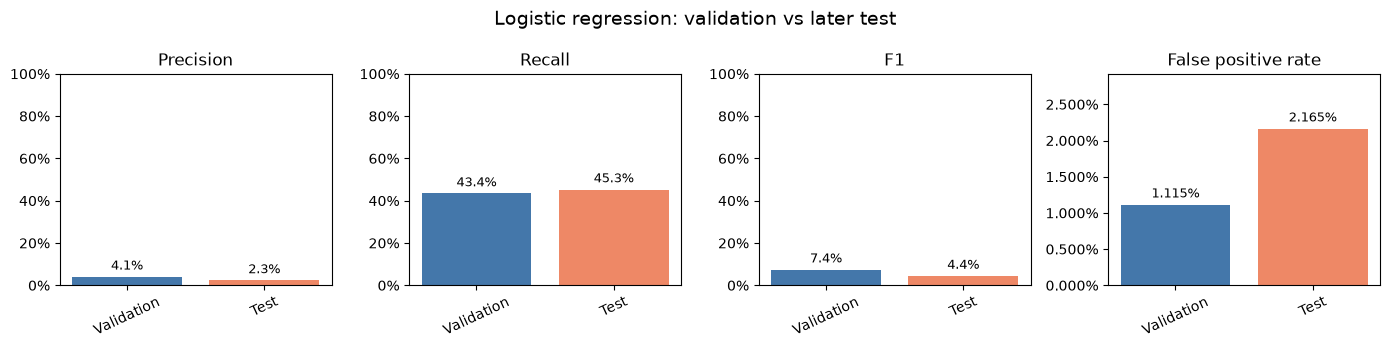

Largest logistic coefficients by absolute size:


prior_pair_count              -1.632793
payment_format_ACH             1.073785
same_account                  -0.697809
prior_sender_count             0.582873
same_bank                     -0.412871
payment_format_Wire           -0.301557
payment_format_Reinvestment   -0.282549
payment_format_Cheque         -0.257240
log_amount                     0.226734
log_amount_received            0.196457
dtype: float32

In [8]:
show_model_scorecard("Logistic regression")

logistic = models["Logistic regression"].named_steps["logisticregression"]
coefficients = pd.Series(logistic.coef_[0], index=X_train.columns)
print("Largest logistic coefficients by absolute size:")
display(coefficients.reindex(coefficients.abs().sort_values(ascending=False).index).head(10))

### 7.2 XGBoost

XGBoost has the highest validation AP, so it is the selected model. On the later test period it finds **177 of 488** positive labels in **495 alerts**: **35.8% precision**, **36.3% recall**, **0.360 F1**, and **0.074% FPR**. That meets all four illustrative classroom goals, though it still misses 311 positive labels. The Tree SHAP values below explain **one high-scored row** in raw model-score units; they do not prove laundering.

XGBoost — validation-selected threshold: 0.3109


,average_precision,precision,recall,f1,false_positive_rate,alerts,true_positives,false_positives
period,,,,,,,,
validation,0.4427,0.6378,0.3805,0.4766,0.0002,312,199,113
test,0.3282,0.3576,0.3627,0.3601,0.0007,495,177,318


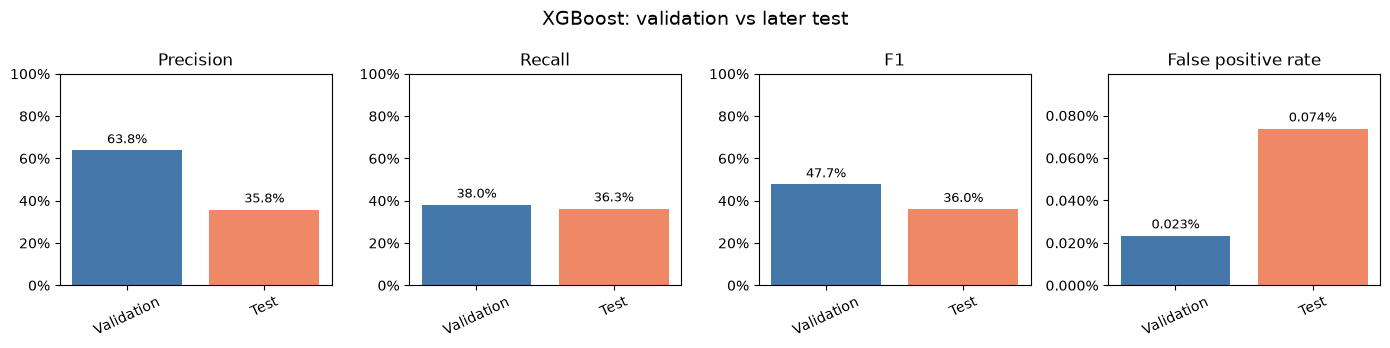

Largest Tree SHAP contributions for one high-scored test row:


payment_format_ACH                  3.222124
prior_sender_count                  1.089105
log_prior_sender_mean_amount        0.902370
prior_pair_count                    0.667183
payment_currency_Canadian Dollar    0.630457
log_amount                          0.553850
log_amount_received                 0.388030
prior_receiver_count                0.273940
hour                                0.110430
same_account                        0.049488
dtype: float32

In [9]:
show_model_scorecard("XGBoost")

xgboost = models["XGBoost"]
most_flagged = np.argmax(scores[("XGBoost", "test")])
contributions = xgboost.get_booster().predict(
    DMatrix(X_test.iloc[[most_flagged]]), pred_contribs=True
)[0][:-1]
shap_values = pd.Series(contributions, index=X_train.columns)
print("Largest Tree SHAP contributions for one high-scored test row:")
display(shap_values.reindex(shap_values.abs().sort_values(ascending=False).index).head(10))

### 7.3 Explainable Boosting Machine (EBM)

EBM raises **263 test alerts** with **125 true positives** and **138 false positives**. Its **47.5% precision** and **0.032% FPR** are better than XGBoost's, but its **25.6% recall** misses more positive labels; **F1 is 0.333**. This is a different precision–recall tradeoff, not a universal winner or loser. EBM's term importances below summarize global model influence; they do not explain a specific transaction.

EBM — validation-selected threshold: 0.5227


,average_precision,precision,recall,f1,false_positive_rate,alerts,true_positives,false_positives
period,,,,,,,,
validation,0.3829,0.7801,0.2849,0.4174,0.0001,191,149,42
test,0.2756,0.4753,0.2561,0.3329,0.0003,263,125,138


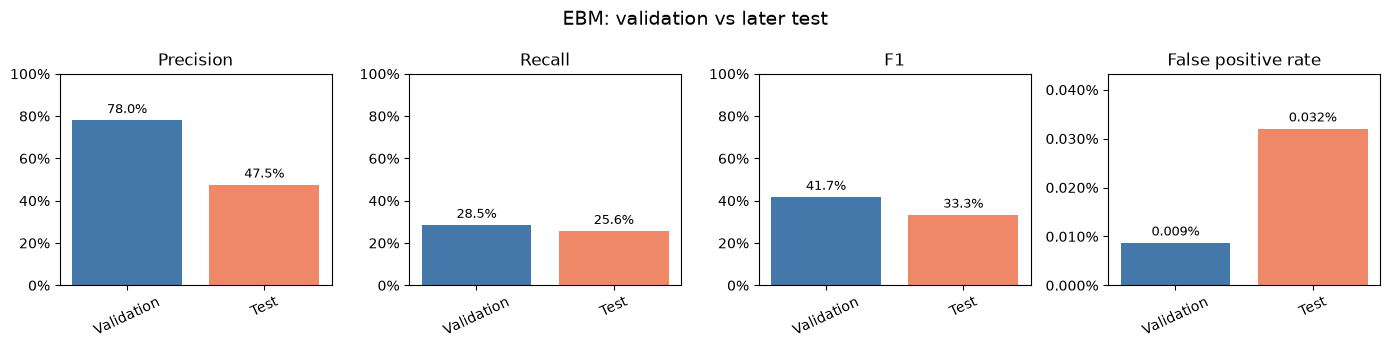

Most important EBM terms overall:


prior_sender_count              1.190896
prior_pair_count                1.105505
log_prior_sender_mean_amount    1.067080
payment_format_ACH              0.771350
same_account                    0.473109
payment_format_Cheque           0.430535
payment_format_Credit Card      0.337173
prior_receiver_count            0.302869
payment_format_Reinvestment     0.296715
log_amount                      0.295556
dtype: float64

In [10]:
show_model_scorecard("EBM")

ebm = models["EBM"]
ebm_terms = pd.Series(ebm.term_importances(), index=ebm.term_names_)
print("Most important EBM terms overall:")
display(ebm_terms.sort_values(ascending=False).head(10))

## 8. What this MVP can claim

This notebook demonstrates a **time-based comparison of three models on sampled synthetic transactions**. The sender, receiver, pair, and prior-average features see only sampled earlier transactions, so they understate complete account activity. All raw transaction fields are read; account and bank IDs remain available in `transactions` and are represented to the model through history and relationship features. They help capture part of the transaction network, but this is not the full graph modeling used in the [original IBM study](https://papers.nips.cc/paper/2023/file/5f38404edff6f3f642d6fa5892479c42-Paper-Datasets_and_Benchmarks.pdf). Its published F1 scores use a different feature pipeline and split, so they are not directly comparable with this notebook.

An exploratory XGBoost check helps explain the gain: at 50% sampling and positive-class weight 10, the previous simple features gave validation AP **0.0602**; adding earlier receiver and sender–receiver counts raised it to **0.2164**; adding the extra current-transaction fields raised it to **0.2349**; and adding the sender’s earlier same-currency mean payment raised it to **0.4427**. Doubling the old sample alone, while keeping the old features and weight, barely changed reporting-period AP (**0.0366** to **0.0367**). More rows alone were not the main fix.

On the September 9–10 reporting period, selected XGBoost finds **177 of 488** positive labels in **495 alerts**: precision **35.8%**, recall **36.3%**, F1 **0.360**, and false positive rate **0.074%**. These meet this notebook’s illustrative class-project goals, but they are not bank acceptance criteria. The September 11–18 data has a sharp volume and label-rate shift and is excluded. We also looked at the September 9–10 results while improving this MVP, so those results are **exploratory**, not an untouched final estimate. Class weighting helps with rare labels, but scores are **not calibrated probabilities**. The figures are educational, not operational AML validation. The CSV has no investigator decisions or SAR outcomes, so this notebook cannot evaluate those outcomes. Databricks and dbt remain possible future data-engineering tools, as described in the [project guide](docs/PROJECT_GUIDE.md).

### How this relates to bank AML monitoring

Banks may combine transaction reports, rules, intelligent surveillance, and referrals to create alerts. Investigators examine customer and transaction context before deciding whether activity warrants a Suspicious Activity Report. The [FFIEC BSA/AML Examination Manual](https://bsaaml.ffiec.gov/manual/AssessingComplianceWithBSARegulatoryRequirements/04) describes these steps and notes that monitoring depends on each bank's risks. Current [Federal Reserve model-risk guidance](https://www.federalreserve.gov/frrs/guidance/supervisory-guidance-on-model-risk-management.htm) includes out-of-time testing and ongoing monitoring among sound practices. The guidance reviewed here does not prescribe a universal metric list or require every raw field to be a direct predictor. The [2026 interagency model-risk guidance](https://www.federalreserve.gov/supervisionreg/srletters/SR2602a1.pdf) calls for input and testing choices aligned with the model’s purpose. Our three-model comparison covers model scoring and synthetic-label alerts only. The numerical target above is a classroom benchmark, not evidence that a model would be ready for a bank.